# 01 · Exploratory data analysis

Coverage, sampling, stage distributions, heart rate and movement by stage, a sampling-rate confound check, and Dreem vs expert agreement. Everything is read from the epoch table built by `sleepwatch data build-epochs` (feature set `v1`), so the notebook sees exactly the verified, aligned data that experiments use.

Numbers here describe the data; they are not model results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import cohen_kappa_score, confusion_matrix

from sleepwatch.config import get_settings
from sleepwatch.constants import STAGE_NAMES, TO_4CLASS, UNKNOWN
from sleepwatch.features.build import load_build

epochs, quality, info = load_build("v1", get_settings().processed_dir)
labeled = epochs[epochs["labeled"]].copy()
labeled["stage"] = pd.Categorical(
    labeled["expert"].map(STAGE_NAMES), categories=[STAGE_NAMES[k] for k in range(5)], ordered=True
)
partial = info["nights"] < info["nights_listed"]
print(
    f"{info['nights']}/{info['nights_listed']} nights, {info['subjects']} subjects, "
    f"{info['epochs']} epochs (built {info['created']}, commit {info['git']['commit'][:8]})"
)
if partial:
    print(
        "PARTIAL DATASET: development sanity check only - rerun on all 253 nights before "
        "drawing conclusions."
    )

# Chart style: categorical slots in fixed order, recessive axes, thin marks.
STAGE_COLORS = {
    "Wake": "#2a78d6",
    "N1": "#eb6834",
    "N2": "#1baf7a",
    "N3": "#eda100",
    "REM": "#e87ba4",
    "Unknown": "#a9a8a3",
}
SEQ = LinearSegmentedColormap.from_list(
    "blue", ["#fcfcfb", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
)
plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)

52/253 nights, 9 subjects, 45125 epochs (built 2026-09-30T12:52:01Z, commit 803c5b54)
PARTIAL DATASET: development sanity check only - rerun on all 253 nights before drawing conclusions.


## 1 · Coverage

Nights per subject, recorded hours, and how much of each night has usable signal.

,nights,hours,hr_coverage,motion_coverage
subject,,,,
Bidslab00,7,51.43,1.00,1.00
Bidslab01,5,36.15,0.93,0.93
Bidslab02,6,44.00,0.94,0.94
Bidslab06,4,27.64,1.00,1.00
Bidslab07,7,51.29,1.00,1.00
Bidslab08,7,46.90,1.00,0.88
Bidslab09,5,31.41,0.98,0.97
Bidslab10,6,46.17,0.99,1.00
Bidslab11,5,41.05,1.00,1.00


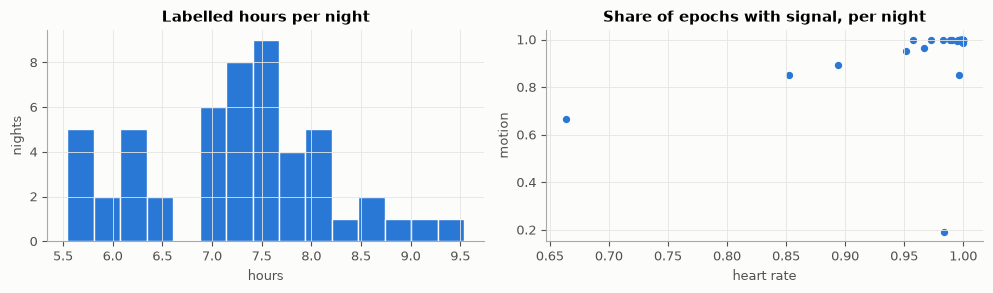

Epochs without HR: 1.6%, without motion: 3.4%


,subject,night,hr_coverage,motion_coverage,hr_start_offset_min,hr_end_offset_min,motion_start_offset_min,motion_end_offset_min
9,Bidslab01,3,0.66,0.66,0.15,-153.91,-0.01,-153.89
12,Bidslab02,1,0.85,0.85,-0.11,-74.96,-0.21,-74.83
15,Bidslab02,4,0.89,0.89,47.57,1444.24,47.48,1444.29
35,Bidslab08,7,0.98,0.19,-1.87,433.36,-2.21,547.23
37,Bidslab09,2,1.00,0.85,1.14,-0.26,-1.04,-0.21


In [2]:
per_subject = quality.groupby("subject").agg(
    nights=("night", "size"),
    hours=("n_epochs", lambda n: n.sum() * 30 / 3600),
    hr_coverage=("hr_coverage", "mean"),
    motion_coverage=("motion_coverage", "mean"),
)
display(per_subject.round(2))

hours = quality["n_epochs"] * 30 / 3600
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(hours, bins=15, color="#2a78d6", edgecolor="#fcfcfb")
ax[0].set(title="Labelled hours per night", xlabel="hours", ylabel="nights")
cov = quality[["hr_coverage", "motion_coverage"]].sort_values("hr_coverage")
ax[1].scatter(cov["hr_coverage"], cov["motion_coverage"], s=18, color="#2a78d6")
ax[1].set(title="Share of epochs with signal, per night", xlabel="heart rate", ylabel="motion")
plt.tight_layout()
plt.show()

print(
    f"Epochs without HR: {(epochs.qc_hr_coverage == 0).mean():.1%}, "
    f"without motion: {(epochs.qc_motion_coverage == 0).mean():.1%}"
)
low = quality[(quality["hr_coverage"] < 0.9) | (quality["motion_coverage"] < 0.9)]
display(
    low[
        [
            "subject",
            "night",
            "hr_coverage",
            "motion_coverage",
            "hr_start_offset_min",
            "hr_end_offset_min",
            "motion_start_offset_min",
            "motion_end_offset_min",
        ]
    ].round(2)
)

## 2 · Signal files vs the label window

Minutes between the first/last raw sample and the start/end of the labelled window. Positive start offsets mean the watch started late; negative end offsets mean it stopped early. Everything outside the window is cropped by the loader.

In [3]:
offsets = quality[
    ["hr_start_offset_min", "hr_end_offset_min", "motion_start_offset_min", "motion_end_offset_min"]
]
display(offsets.describe().round(1))

,hr_start_offset_min,hr_end_offset_min,motion_start_offset_min,motion_end_offset_min
count,52.0,52.0,52.0,52.0
mean,0.7,443.6,0.4,446.6
std,7.8,915.4,7.8,915.3
min,-6.6,-153.9,-6.8,-153.9
25%,-1.5,-0.6,-1.7,-0.4
50%,-0.6,-0.2,-0.7,-0.1
75%,0.4,283.1,0.1,330.8
max,47.6,4322.1,47.5,4322.1


## 3 · Sampling rates

HR interval and motion sampling rate per night (median over the raw file).

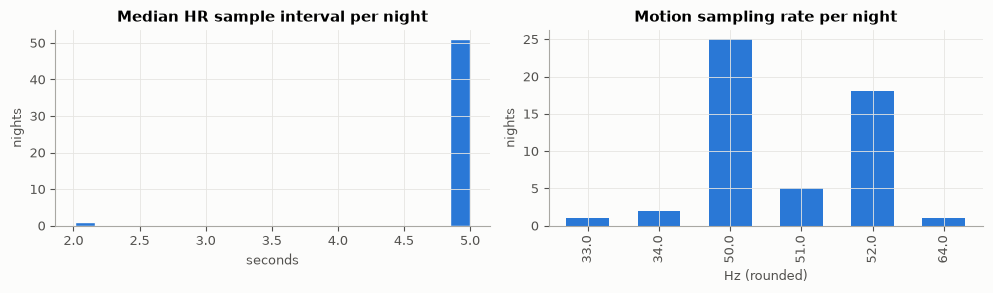

,hr_median_dt_s,motion_hz
count,52.00,52.0
mean,4.94,50.1
std,0.41,4.6
min,2.01,33.0
25%,5.00,50.0
50%,5.00,50.0
75%,5.00,52.0
max,5.00,64.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(quality["hr_median_dt_s"], bins=20, color="#2a78d6", edgecolor="#fcfcfb")
ax[0].set(title="Median HR sample interval per night", xlabel="seconds", ylabel="nights")
hz = (1 / quality["motion_median_dt_s"]).round()
hz.value_counts().sort_index().plot.bar(ax=ax[1], color="#2a78d6", width=0.6)
ax[1].set(title="Motion sampling rate per night", xlabel="Hz (rounded)", ylabel="nights")
plt.tight_layout()
plt.show()
display(
    pd.DataFrame(
        {
            "hr_median_dt_s": quality["hr_median_dt_s"].describe().round(2),
            "motion_hz": hz.describe().round(1),
        }
    )
)

## 4 · Stage distribution (expert labels)

expert,Wake,N1,N2,N3,REM,Unknown
share,0.104,0.071,0.375,0.189,0.256,0.004


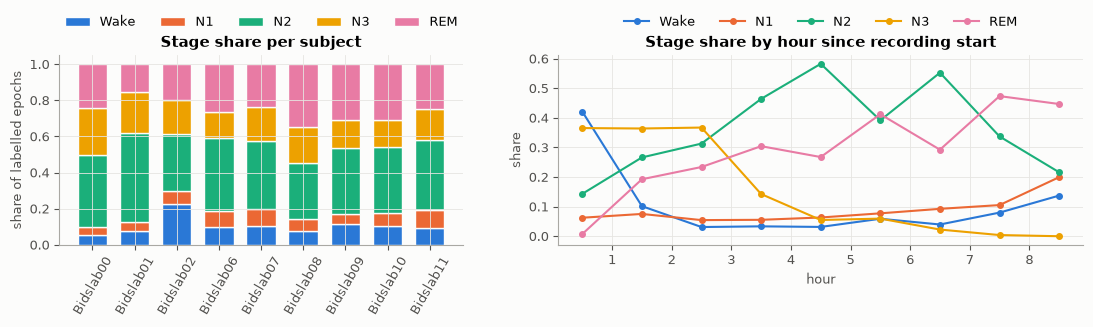

stage,Wake,N1,N2,N3,REM
subject,,,,,
Bidslab00,0.052,0.046,0.399,0.261,0.242
Bidslab01,0.079,0.050,0.492,0.226,0.153
Bidslab02,0.224,0.076,0.312,0.190,0.198
Bidslab06,0.101,0.086,0.404,0.146,0.263
Bidslab07,0.104,0.092,0.380,0.184,0.239
Bidslab08,0.077,0.063,0.313,0.200,0.347
Bidslab09,0.117,0.055,0.364,0.157,0.307
Bidslab10,0.104,0.073,0.367,0.145,0.311
Bidslab11,0.092,0.102,0.389,0.170,0.247


In [5]:
names = [STAGE_NAMES[k] for k in range(6)]
overall = epochs["expert"].map(STAGE_NAMES).value_counts(normalize=True).reindex(names).fillna(0)
display(overall.rename("share").to_frame().T.round(3))

per_subject_stage = (
    labeled.groupby("subject", observed=True)["stage"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.3]})
bottom = np.zeros(len(per_subject_stage))
for stage in per_subject_stage.columns:
    ax[0].bar(
        per_subject_stage.index,
        per_subject_stage[stage],
        bottom=bottom,
        width=0.7,
        color=STAGE_COLORS[stage],
        edgecolor="#fcfcfb",
        linewidth=1,
        label=stage,
    )
    bottom += per_subject_stage[stage].to_numpy()
ax[0].set(title="Stage share per subject", ylabel="share of labelled epochs")
ax[0].tick_params(axis="x", rotation=60)
ax[0].legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.08))

labeled["hour"] = labeled["hours_since_start"].astype(int)
by_hour = (
    labeled[labeled["hour"] < 9].groupby("hour")["stage"].value_counts(normalize=True).unstack()
)
for stage in by_hour.columns:
    ax[1].plot(
        by_hour.index + 0.5,
        by_hour[stage],
        color=STAGE_COLORS[stage],
        marker="o",
        ms=4,
        label=stage,
    )
ax[1].set(title="Stage share by hour since recording start", xlabel="hour", ylabel="share")
ax[1].legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()
display(per_subject_stage.round(3))

## 5 · Heart rate by stage

Absolute HR differs a lot between people, so pooled medians mix subjects. The left panel shows each subject's median HR per stage; the right panel uses HR relative to the night's median (`hr_rel`), which removes the person-level offset. Stage and time of night are entangled (N3 is concentrated early, when HR is still falling), so the table below also splits by the first vs the rest of the night.

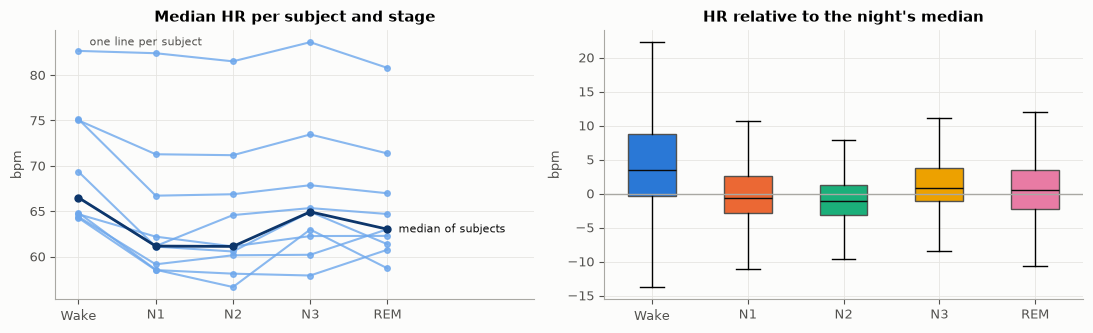

stage,Wake,N1,N2,N3,REM
subject,,,,,
Bidslab00,64.3,58.5,58.1,57.9,60.8
Bidslab01,64.8,58.6,56.6,63.0,58.7
Bidslab02,75.1,66.7,66.9,67.9,67.0
Bidslab06,64.4,59.2,60.1,60.2,63.0
Bidslab07,75.0,71.3,71.2,73.5,71.4
Bidslab08,69.4,61.1,60.6,64.9,61.4
Bidslab09,66.5,61.2,64.6,65.3,64.7
Bidslab10,64.7,62.2,61.1,62.3,62.3
Bidslab11,82.7,82.4,81.5,83.6,80.8


part,after 3 h,first 3 h
stage,,
Wake,0.37,4.86
N1,-1.50,1.37
N2,-1.68,1.14
N3,-0.53,1.25
REM,-0.38,3.42


In [6]:
subj_hr = labeled.groupby(["subject", "stage"], observed=True)["hr_mean"].median().unstack()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for _subject, row in subj_hr.iterrows():
    ax[0].plot(range(len(row)), row.to_numpy(), color="#6da7ec", marker="o", ms=4, alpha=0.8)
medians = subj_hr.median().to_numpy()
ax[0].plot(range(subj_hr.shape[1]), medians, color="#0d366b", marker="o", ms=5, lw=2)
ax[0].annotate(
    "median of subjects",
    (subj_hr.shape[1] - 1, medians[-1]),
    textcoords="offset points",
    xytext=(8, 0),
    va="center",
    color="#0b0b0b",
    fontsize=8,
)
ax[0].annotate(
    "one line per subject",
    (0, subj_hr.iloc[:, 0].max()),
    textcoords="offset points",
    xytext=(8, 4),
    color="#52514e",
    fontsize=8,
)
ax[0].set_xticks(range(subj_hr.shape[1]), subj_hr.columns)
ax[0].set_xlim(-0.3, subj_hr.shape[1] + 0.9)
ax[0].set(title="Median HR per subject and stage", ylabel="bpm")

stages = list(subj_hr.columns)
data = [labeled.loc[labeled["stage"] == s, "hr_rel"].dropna() for s in stages]
bp = ax[1].boxplot(
    data,
    tick_labels=stages,
    showfliers=False,
    patch_artist=True,
    widths=0.5,
    medianprops={"color": "#0b0b0b"},
)
for patch, s in zip(bp["boxes"], stages, strict=True):
    patch.set_facecolor(STAGE_COLORS[s])
    patch.set_edgecolor("#52514e")
ax[1].axhline(0, color="#a9a8a3", lw=1)
ax[1].set(title="HR relative to the night's median", ylabel="bpm")
plt.tight_layout()
plt.show()

labeled["part"] = np.where(labeled["hours_since_start"] < 3, "first 3 h", "after 3 h")
display(subj_hr.round(1))
display(
    labeled.pivot_table(
        index="stage", columns="part", values="hr_rel", aggfunc="median", observed=True
    ).round(2)
)

## 6 · Movement by stage

Activity (band-passed acceleration magnitude, g) is heavy-tailed, so it is shown on a log scale.

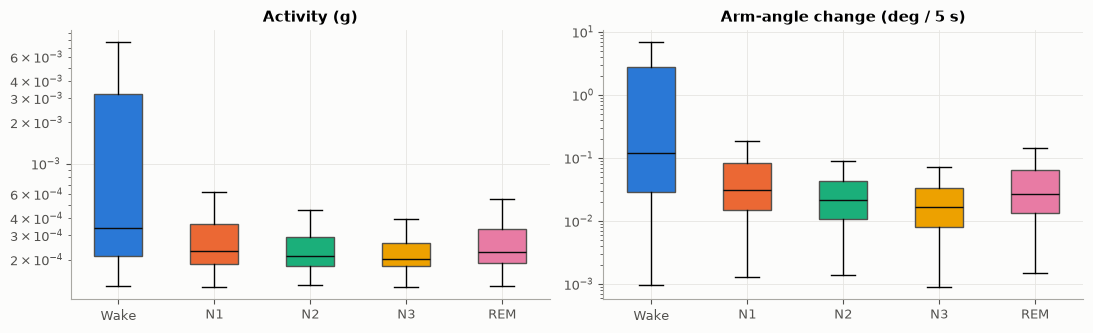

activity           enmo_mean           angle_change          
            0.5       0.9       0.5       0.9          0.5       0.9
stage                                                               
Wake   3.42e-04  3.06e-02  3.18e-03  2.92e-02     1.19e-01  1.25e+01
N1     2.30e-04  3.10e-03  1.20e-03  8.37e-03     3.12e-02  1.94e+00
N2     2.11e-04  4.63e-04  1.11e-03  7.88e-03     2.15e-02  1.18e-01
N3     2.03e-04  4.07e-04  1.38e-03  8.46e-03     1.69e-02  5.85e-02
REM    2.28e-04  1.20e-03  1.15e-03  7.70e-03     2.65e-02  8.30e-01

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for axis, col, title in [
    (ax[0], "activity", "Activity (g)"),
    (ax[1], "angle_change", "Arm-angle change (deg / 5 s)"),
]:
    data = [labeled.loc[labeled["stage"] == s, col].dropna().clip(lower=1e-5) for s in stages]
    bp = axis.boxplot(
        data,
        tick_labels=stages,
        showfliers=False,
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "#0b0b0b"},
    )
    for patch, s in zip(bp["boxes"], stages, strict=True):
        patch.set_facecolor(STAGE_COLORS[s])
        patch.set_edgecolor("#52514e")
    axis.set_yscale("log")
    axis.set(title=title)
plt.tight_layout()
plt.show()
display(
    labeled.groupby("stage", observed=True)[["activity", "enmo_mean", "angle_change"]]
    .quantile([0.5, 0.9])
    .unstack()
    .map(lambda v: f"{v:.2e}")
)

## 7 · Is the HR sampling rate a shortcut?

If the watch recorded heart rate more often in some stages, the raw sample count per epoch would predict the stage for device reasons, not physiological ones. That is why the count is kept as `qc_hr_samples` and excluded from model inputs. This checks how strong the effect is, within night (sample count relative to the night's median).

In [8]:
labeled["hr_samples_rel"] = labeled["qc_hr_samples"] / labeled.groupby(["subject", "night"])[
    "qc_hr_samples"
].transform("median")
display(
    labeled.groupby("stage", observed=True)["hr_samples_rel"]
    .describe()[["mean", "25%", "50%", "75%"]]
    .round(3)
)
night_rate = quality.set_index(["subject", "night"])["hr_median_dt_s"]
wake_share = labeled.groupby(["subject", "night"])["expert"].apply(lambda s: (s == 0).mean())
print(
    f"Spearman correlation, per night, HR interval vs Wake share: "
    f"{night_rate.corr(wake_share, method='spearman'):.2f} (n={len(wake_share)} nights)"
)

,mean,25%,50%,75%
stage,,,,
Wake,0.929,0.833,1.0,1.0
N1,0.946,1.000,1.0,1.0
N2,0.980,1.000,1.0,1.0
N3,0.990,1.000,1.0,1.0
REM,0.984,1.000,1.0,1.0


Spearman correlation, per night, HR interval vs Wake share: -0.10 (n=52 nights)


## 8 · Dreem vs expert agreement

The expert labels are the Dreem labels after a sleep expert's review and correction, so this measures how much the review changed, not the agreement of two independent scorers. Epochs where either label is Unknown are excluded.

Pooled Cohen's kappa: 5-class 0.743, 4-class 0.807; accuracy 0.813 over 44760 epochs


,count,mean,std,min,25%,50%,75%,max
kappa5,52.0,0.737,0.13,-0.027,0.707,0.745,0.804,0.898


,,kappa5,agreement,epochs
subject,night,,,
Bidslab01,4,-0.027,0.222,760.0
Bidslab07,3,0.556,0.678,861.0
Bidslab10,6,0.615,0.720,746.0
Bidslab09,5,0.628,0.722,600.0
Bidslab11,3,0.640,0.748,864.0


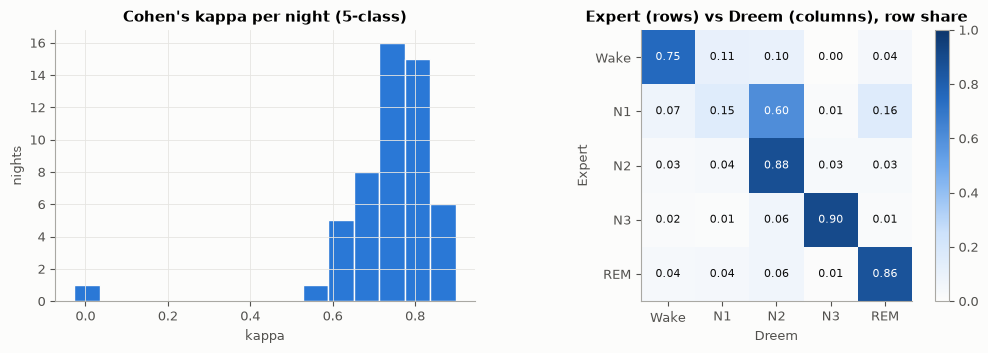

,dreem Wake,dreem N1,dreem N2,dreem N3,dreem REM
expert Wake,3521,496,473,15,188
expert N1,222,475,1854,40,486
expert N2,457,636,14805,497,525
expert N3,128,79,520,7684,114
expert REM,438,457,691,75,9884


In [9]:
both = epochs[(epochs["expert"] != UNKNOWN) & (epochs["dreem"] != UNKNOWN)]
k5 = cohen_kappa_score(both["expert"], both["dreem"])
k4 = cohen_kappa_score(both["expert"].map(TO_4CLASS), both["dreem"].map(TO_4CLASS))
print(
    f"Pooled Cohen's kappa: 5-class {k5:.3f}, 4-class {k4:.3f}; "
    f"accuracy {(both.expert == both.dreem).mean():.3f} over {len(both)} epochs"
)

per_night = both.groupby(["subject", "night"]).apply(
    lambda d: pd.Series(
        {
            "kappa5": cohen_kappa_score(d.expert, d.dreem),
            "agreement": (d.expert == d.dreem).mean(),
            "epochs": len(d),
        }
    ),
    include_groups=False,
)
display(per_night["kappa5"].describe().round(3).to_frame().T)
display(per_night.nsmallest(5, "kappa5").round(3))

labels5 = list(range(5))
names5 = [STAGE_NAMES[k] for k in labels5]
cm = confusion_matrix(both["expert"], both["dreem"], labels=labels5)
cm_rows = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.1]})
ax[0].hist(per_night["kappa5"], bins=15, color="#2a78d6", edgecolor="#fcfcfb")
ax[0].set(title="Cohen's kappa per night (5-class)", xlabel="kappa", ylabel="nights")
im = ax[1].imshow(cm_rows, cmap=SEQ, vmin=0, vmax=1)
ax[1].set_xticks(labels5, names5)
ax[1].set_yticks(labels5, names5)
ax[1].grid(False)
ax[1].set(title="Expert (rows) vs Dreem (columns), row share", xlabel="Dreem", ylabel="Expert")
for i in labels5:
    for j in labels5:
        ax[1].text(
            j,
            i,
            f"{cm_rows[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="#ffffff" if cm_rows[i, j] > 0.55 else "#0b0b0b",
        )
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
plt.show()
display(
    pd.DataFrame(cm, index=[f"expert {n}" for n in names5], columns=[f"dreem {n}" for n in names5])
)

## 9 · Label timing vs the watch signals

The dataset states that every label epoch starts at `recStart + 30k`. This checks it empirically: label epoch *k* is paired with signal epoch *k + lag*, and we measure how well activity (log scale) and heart rate separate Wake from sleep. Movement marks waking sharply, so the lag with the largest separation estimates the timing offset. **A negative best lag means the labels run late.** Night `Bidslab01/4` is excluded here (its expert labels don't match Dreem at any lag; see section 10).

expert vs log_activity: best lag per night -> {-4: 14, -3: 14, -2: 20, -1: 2, 0: 1}


expert vs hr_mean     : best lag per night -> {-4: 11, -3: 16, -2: 13, -1: 10, 2: 1}
dreem  vs log_activity: best lag per night -> {-3: 1, -2: 3, -1: 33, 0: 14}


dreem  vs hr_mean     : best lag per night -> {-2: 2, -1: 13, 0: 36}
expert vs dreem agreement: best lag per night -> {-2: 19, -1: 29, 0: 3}


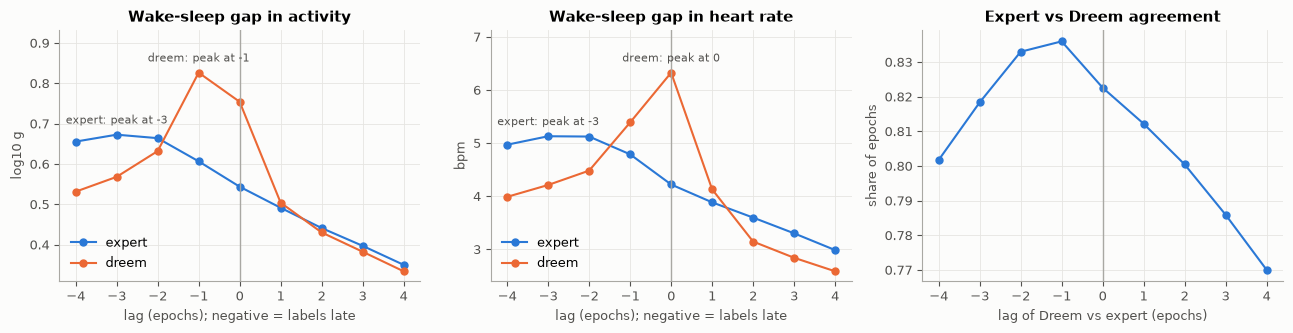

expert                dreem        
    log_activity hr_mean log_activity hr_mean
lag                                          
-4         0.656   4.970        0.531   3.989
-3         0.673   5.130        0.568   4.212
-2         0.664   5.124        0.632   4.482
-1         0.607   4.789        0.826   5.390
 0         0.544   4.221        0.754   6.327
 1         0.491   3.885        0.504   4.129
 2         0.441   3.598        0.430   3.146
 3         0.397   3.301        0.383   2.841
 4         0.350   2.986        0.334   2.587

In [10]:
from sleepwatch.data.label_timing import best_lags, label_agreement_by_lag, wake_separation_by_lag

timing = epochs[~((epochs.subject == "Bidslab01") & (epochs.night == 4))].assign(
    log_activity=lambda d: np.log10(d["activity"].clip(lower=1e-5))
)
curves = {}
for label in ["expert", "dreem"]:
    for feature in ["log_activity", "hr_mean"]:
        sep = wake_separation_by_lag(timing, label, feature)
        curves[(label, feature)] = sep.groupby("lag")["separation"].mean()
        print(
            f"{label:6s} vs {feature:12s}: best lag per night ->",
            best_lags(sep, "separation").value_counts().sort_index().to_dict(),
        )
agree = label_agreement_by_lag(timing, "expert", "dreem")
print(
    "expert vs dreem agreement: best lag per night ->",
    best_lags(agree, "agreement").value_counts().sort_index().to_dict(),
)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for axis, feature, title, unit in [
    (ax[0], "log_activity", "Wake-sleep gap in activity", "log10 g"),
    (ax[1], "hr_mean", "Wake-sleep gap in heart rate", "bpm"),
]:
    for label, color in [("expert", "#2a78d6"), ("dreem", "#eb6834")]:
        curve = curves[(label, feature)]
        axis.plot(curve.index, curve.to_numpy(), color=color, marker="o", ms=5, label=label)
        best = curve.idxmax()
        axis.annotate(
            f"{label}: peak at {best}",
            (best, curve.max()),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            color="#52514e",
            fontsize=8,
        )
    axis.axvline(0, color="#a9a8a3", lw=1)
    low_y, high_y = axis.get_ylim()
    axis.set_ylim(low_y, high_y + 0.15 * (high_y - low_y))
    axis.set(title=title, xlabel="lag (epochs); negative = labels late", ylabel=unit)
    axis.legend(loc="lower left")
mean_agree = agree.groupby("lag")["agreement"].mean()
ax[2].plot(mean_agree.index, mean_agree.to_numpy(), color="#2a78d6", marker="o", ms=5)
ax[2].axvline(0, color="#a9a8a3", lw=1)
ax[2].set(
    title="Expert vs Dreem agreement",
    xlabel="lag of Dreem vs expert (epochs)",
    ylabel="share of epochs",
)
plt.tight_layout()
plt.show()
display(pd.DataFrame(curves).round(3))

## 10 · Data-quality flags

In [11]:
flags = quality.assign(
    dreem_length_mismatch=quality["n_dreem_raw"] != quality["n_epochs"],
    has_unknown=quality["n_unknown"] > 0,
    hr_duplicates=quality["hr_duplicate_ts"] > 0,
    motion_duplicates=quality["motion_duplicate_ts"] > 0,
    not_chronological=~quality["chronological"],
)
cols = [
    "dst_ambiguous",
    "dreem_length_mismatch",
    "has_unknown",
    "hr_duplicates",
    "motion_duplicates",
    "not_chronological",
]
display(flags[cols].sum().rename("nights").to_frame().T)
display(
    flags.loc[
        flags[cols].any(axis=1), ["subject", "night", *cols, "n_unknown", "n_dreem_raw", "n_epochs"]
    ]
)

,dst_ambiguous,dreem_length_mismatch,has_unknown,hr_duplicates,motion_duplicates,not_chronological
nights,0,1,11,2,0,0


,subject,night,dst_ambiguous,dreem_length_mismatch,has_unknown,hr_duplicates,motion_duplicates,not_chronological,n_unknown,n_dreem_raw,n_epochs
5,Bidslab00,6,False,False,True,False,False,False,1,886,886
10,Bidslab01,4,False,True,True,False,False,False,11,935,771
11,Bidslab01,5,False,False,True,False,False,False,13,911,911
15,Bidslab02,4,False,False,False,True,False,False,0,899,899
28,Bidslab07,7,False,False,True,False,False,False,4,766,766
29,Bidslab08,1,False,False,True,False,False,False,1,831,831
31,Bidslab08,3,False,False,True,True,False,False,2,760,760
33,Bidslab08,5,False,False,True,False,False,False,7,691,691
39,Bidslab09,4,False,False,True,False,False,False,25,672,672
40,Bidslab09,5,False,False,True,False,False,False,46,675,675


## Findings so far (partial data: 52 nights, 9 subjects, 2026-09-30)

Provisional, and to be rewritten once all 253 nights are verified. None of this is a model result.

- **Coverage is good but not perfect.** 1.6% of epochs have no heart rate and 3.4% no motion. Five nights are under 90% on one signal: the watch stopped 154 min early on `Bidslab01/3`, and `Bidslab08/7` has motion for only 19% of the night. The coverage masks keep these epochs out of feature statistics rather than interpolating over them.
- **Sampling differs between nights.** Heart rate comes every 5 s on 51 nights and every 2 s on one; motion is ~50 Hz except three ~33 Hz nights and one ~64 Hz night. The features are built on uniform grids, and tests check that they agree across rates.
- **Stage mix is typical for healthy adults.** Wake 10%, N1 7%, N2 38%, N3 19%, REM 26%. N3 sits mostly in the first 3 hours and REM rises through the night, so time of night carries real information and is also a confound.
- **Heart rate is mostly about the person.** Subject medians range from about 58 to 83 bpm, far more than the differences between stages. Relative to the night's median, Wake is about 3.5 bpm higher and N2 is lowest. N3 looks higher than N2 when pooled, but splitting by time of night shows every stage runs higher in the first 3 hours; this is why personal and time-of-night baselines matter.
- **Movement separates Wake well and the sleep stages poorly.** N1 and REM move a little more than N2 and N3, but the distributions overlap heavily. Expect N1 to be the hardest stage.
- **The heart-rate sample count is a small device shortcut.** Wake epochs have about 7% fewer HR samples than the night's median. The count is therefore kept as a `qc_` column and never used as a model input.
- **Dreem vs expert:** pooled Cohen's kappa 0.74 (5-class) and 0.81 (4-class). Most disagreement is N1: expert N1 is Dreem N2 60% of the time. This is a review of Dreem, not an independent second scorer, so it is not an inter-rater benchmark.
- **The expert labels appear to run late.** With the documented alignment, activity and heart rate separate expert-Wake from sleep best when labels are paired with signals 2-3 epochs (60-90 s) earlier; Dreem labels line up within one epoch. Expert labels also match Dreem best shifted by 1-2 epochs. The dataset documentation says both share `recStart` and doesn't mention an offset. **Whether to correct for it is an open decision for Phase 2.**
- **`Bidslab01/4` has suspect expert labels.** They are 771 epochs against Dreem's 935, agree with Dreem on 22% of epochs (kappa -0.03), and no shift within +-200 epochs repairs this. Proposed: exclude this night from evaluation and report the exclusion.